<head>
    <style>
      .jupyter-wrapper table.dataframe tr, .jupyter-wrapper table.dataframe th, .jupyter-wrapper table.dataframe td {
          text-align:left;
      }
        table, th{
        direction: revert;
        border: 1px solid black;
        width: 200px;
        }
        th:nth-child(1){
            width:290px;
            }
        th:nth-child(2){
            width:230px;
            }
        th:nth-child(3){
            width:50px;
            }
      </style>
</head>

# Co-citations of Top Management Journals 

<img class="zoom-jupyter" src="/images/inno-community.png">

## Introduction 

In this post, I will try to build up a co-citation network for the following
top 10 management journals with searching keyword `innovation` in the title and
abstract. 

* Administrative Science Quarterly
* Academy of Management Journal
* Academy of Management Review
* Strategic Management Journal
* Organization Science
* Management Science
* Research Policy
* Journal of Financial Economics
* Technovation
* Technological Forecasting and Social Change

<div class="result">
    <details class="note"> 
        <summary>Link for the dataset</summary> 
        CSV files that include key information like title, authors, and citations.
        You can download via my
        <a href="https://drive.google.com/drive/folders/1Cll6Xq1YL3AzDn4ZDsTaIETeomCf0glF?usp=sharing">
        google driver. 
        </a>
    </details> 
</div>

Please make sure you have installed the essential packages we will use. 

In [32]:
# install and load essential packages
# install and import libraries 
package_list <- c(
  "tidyverse",  # this package is essential 
  "janitor", # useful functions for cleaning imported data
  "biblionetwork", # creating edges
  "tidygraph", # for creating networks
  "ggraph", # plotting networks
  "ggdark",  # dark theme 
  "flowCore",  # flow network
  "vite",
  "networkflow",
  "gt",  # a beautiful table,
  "ragg"  # a graph library
)
for (p in package_list) {
  if (p %in% installed.packages() == FALSE) {
    install.packages(p, dependencies = TRUE)
  }
  library(p, character.only = TRUE)
}

## Read and clean the dataset 

In [ ]:
data <- read_csv("/Users/Michael/Desktop/Core/innomgmt1.csv", skip=1)
for (i in c(2:3)) {
    path <- "/Users/Michael/Desktop/Core/innomgmt"
    file_path <- paste(path, as.character(i), ".csv", sep="")
    temp <- read_csv(file_path, skip=1)
    # combine the dataset and 
    data <- rbind(data, temp)
}

In [48]:
print(dim(data))  # 5658 articles 

[1] 5658   15


In [6]:
print(names(data))

 [1] "Publication ID"                                         
 [2] "DOI"                                                    
 [3] "Title"                                                  
 [4] "Abstract"                                               
 [5] "Source title/Anthology title"                           
 [6] "PubYear"                                                
 [7] "Volume"                                                 
 [8] "Issue"                                                  
 [9] "Pagination"                                             
[10] "Authors"                                                
[11] "Authors Affiliations - Name of Research organization"   
[12] "Authors Affiliations - Country of Research organization"
[13] "Dimensions URL"                                         
[14] "Times cited"                                            
[15] "Cited references"                                       


In [49]:
# clean the column names (lower case with _)
data <- clean_names(data)
names(data)[5] <- "source"
names(data)[11] <- "organization" 
names(data)[12] <- "country"
names(data)[13] <- "url"
print(names(data))

 [1] "publication_id"   "doi"              "title"            "abstract"        
 [5] "source"           "pub_year"         "volume"           "issue"           
 [9] "pagination"       "authors"          "organization"     "country"         
[13] "url"              "times_cited"      "cited_references"


In [248]:
# peek the dataframe, select some columns 
head(data[c(3, 1, 2, 6, 14)])

title,publication_id,doi,pub_year,times_cited
<chr>,<chr>,<chr>,<dbl>,<dbl>
Sustainability transitions: An emerging field of research and its prospects,pub.1049230838,10.1016/j.respol.2012.02.013,2012,1664
How open is innovation?,pub.1030289250,10.1016/j.respol.2010.01.013,2010,1503
Developing a framework for responsible innovation,pub.1002596470,10.1016/j.respol.2013.05.008,2013,1335
Value creation in innovation ecosystems: how the structure of technological interdependence affects firm performance in new technology generations,pub.1049751245,10.1002/smj.821,2009,1260
"Open innovation in SMEs: Trends, motives and management challenges",pub.1019587175,10.1016/j.technovation.2008.10.001,2009,1176
Exploitation-Exploration Tensions and Organizational Ambidexterity: Managing Paradoxes of Innovation,pub.1064732485,10.1287/orsc.1080.0406,2009,1126


In [51]:
# check duplicates
print(dim(data[duplicated(data$title),]))  ## 114 

[1] 32 15


In [52]:
# drop the duplicates
data <- data[!duplicated(data$title), ]
print(dim(data))  # 5658 (total articles) - 32 = 5626

[1] 5626   15


In [370]:
# check the top citations
data %>%
    arrange(desc(times_cited)) %>% 
    select(title, authors, times_cited) %>%
    head(10)

title,authors,times_cited
<chr>,<chr>,<int>
Absorptive Capacity: A New Perspective on Learning and Innovation,"Cohen, Wesley M.; Levinthal, Daniel A.",18870
Toward a knowledge‐based theory of the firm,"Grant, Robert M.",8053
"Profiting from technological innovation: Implications for integration, collaboration, licensing and public policy","Teece, David J.",5827
Explicating dynamic capabilities: the nature and microfoundations of (sustainable) enterprise performance,"Teece, David J.",5817
Interorganizational Collaboration and the Locus of Innovation: Networks of Learning in Biotechnology,"Powell, Walter W.; Koput, Kenneth W.; Smith-Doerr, Laurel",5049
Architectural Innovation: The Reconfiguration of Existing Product Technologies and the Failure of Established Firms,"Henderson, Rebecca M.; Clark, Kim B.",4736
"Organizational Learning and Communities-of-Practice: Toward a Unified View of Working, Learning, and Innovation","Brown, John Seely; Duguid, Paul",4679
Technological paradigms and technological trajectories A suggested interpretation of the determinants and directions of technical change,"Dosi, Giovanni",4009
Core capabilities and core rigidities: A paradox in managing new product development,"Leonard‐Barton, Dorothy",3907


<div class="result">
    <details class="warning"> 
        <summary>Warning</summary> 
        Since we search for articles based on keyword <em>innovation</em>
        in the title and abstract, therefore some very influential papers
        were not selected, such as: 
        <br>
        Dynamic capabilities and strategic management, 
        David J. Teece, Gary Pisano, Amy Shuen, 
        1997, Strategic Management Journal - Article
    </details> 
</div>

In [54]:
# create a table by mapping each author to is affiliation
article_affiliation <- data %>%
                       select(publication_id, organization, country) %>%
                       separate_rows(c("organization","country"), sep=";")
head(article_affiliation)  # what a beautiful table (see publication_id)

publication_id,organization,country
<chr>,<chr>,<chr>
pub.1049230838,Swiss Federal Institute of Aquatic Science and Technology,Switzerland
pub.1049230838,Eindhoven University of Technology,Netherlands
pub.1030289250,Stanford University,United States
pub.1030289250,Imperial College London,United Kingdom
pub.1002596470,University College London,United Kingdom
pub.1002596470,University of Exeter,United Kingdom


In [55]:
# define a function to remove the first space 
# for example " USA" should == "USA"
clean_strings <- function(strings) {
    str_len = nchar(strings)
    first_char <- substr(strings, 1, 1)
    if(identical(first_char, ' ')) {
        return(substr(strings, 2, str_len))
    } else {
        return(strings)
    }
}
for (i in 1:nrow(article_affiliation)) {
    for (j in 1:ncol(article_affiliation)){
        article_affiliation[i, j] <- clean_strings(article_affiliation[i, j])
    }
}

In [63]:
# get the top 10 publishing countries
top_publishing_country <- article_affiliation %>%
                    # drop NaN
                    dplyr::filter(!is.na(country)) %>%
                    # count frequency of each observation's country
                    count(country) %>%
                    # calculate share 
                    mutate(country_share = n/sum(n)) %>%
                    # ranking based on country share 
                    slice_max(order_by = country_share, n = 10, 
                                                    with_ties = F)
top_publishing_country

country,n,country_share
<chr>,<int>,<dbl>
United States,1859,0.20290330
United Kingdom,1362,0.14865750
China,701,0.07651168
Germany,529,0.05773849
Netherlands,529,0.05773849
Italy,520,0.05675617
Spain,357,0.03896529
France,336,0.03667322
Canada,230,0.02510369


In [65]:
# get the top 10 publishing organizations 
top_publishing_org <- article_affiliation %>%
                    # drop NaN
                    dplyr::filter(!is.na(organization)) %>%
                    # count frequency of each observation's country
                    count(organization) %>%
                    # calculate share 
                    mutate(organization_share = n/sum(n)) %>%
                    # ranking based on country share 
                    slice_max(order_by = organization_share, n = 10, 
                                                            with_ties = F)
top_publishing_org

organization,n,organization_share
<chr>,<int>,<dbl>
University of Sussex,154,0.016808557
University of Manchester,113,0.012333552
Utrecht University,93,0.010150622
Massachusetts Institute of Technology,87,0.009495743
Harvard University,83,0.009059157
Georgia Institute of Technology,76,0.008295132
University of Cambridge,65,0.007094521
Copenhagen Business School,61,0.006657935
Erasmus University Rotterdam,58,0.006330496


In [235]:
plot1 <- ggplot(top_publishing_country,aes(x=reorder(country, n),
                        y=n, fill=0))+coord_flip()+ geom_col()+ 
                        geom_text(aes(label = n), hjust = 1.3, 
                        color='white') + xlab('Country')+ 
                        ggtitle("Top 10 Publishing Countries")+
                        theme(legend.position = "none",
                        plot.title = element_text(hjust = 0.5),
                        axis.text.y = element_blank(),
                        axis.title.y = element_blank()) +
                        annotate("text", x = 10:8, y = 330,
                        label = top_publishing_country$country[1:3],
                        color='white', size=5)
plot2 <- ggplot(top_publishing_org,aes(x=reorder(organization, n), 
                        y=n, fill='red'))+coord_flip()+ geom_col()+ 
                        xlab('Organizations')+ 
                        ggtitle("Top 10 Publishing Organizations")+
                        geom_text(aes(label = n), hjust = 1.3, 
                        color='black') + xlab('Country')+
                        theme(legend.position = "none",
                        plot.title = element_text(hjust = 0.5),
                        axis.text.y = element_blank(),
                        axis.title.y = element_blank()) +
                        annotate("text", x = 10:8, y = 50,
                        label = top_publishing_org$organization[1:3],
                        color='black', size=5)

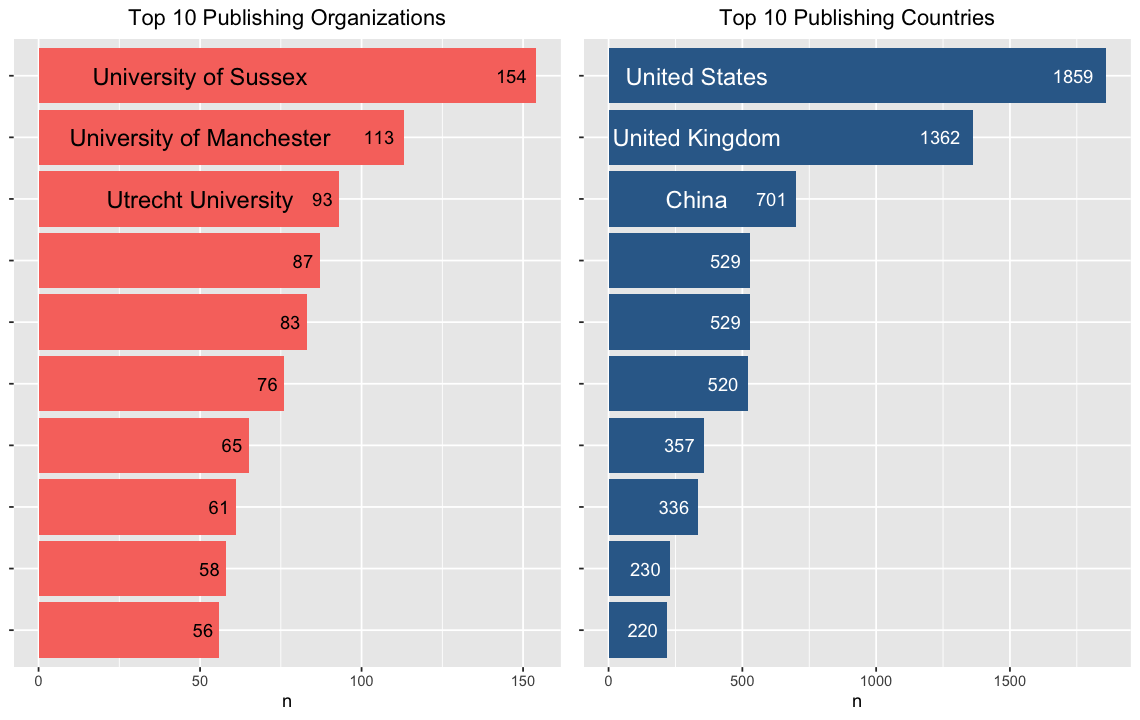

In [236]:
library(repr)
options(repr.plot.width=9.5, repr.plot.height=6)
require(gridExtra)
grid.arrange(plot2, plot1, ncol=2)

## Map references

In [238]:
# map references 
references_map <- data %>%
        dplyr::filter(!is.na(cited_references)) %>%
        rename("citing_id"=publication_id) %>%
        select(citing_id, cited_references) %>%
        # match ; until [
        separate_rows(cited_references, sep=";(?=\\[)") %>%
        as_tibble
head(references_map)

citing_id,cited_references
<chr>,<chr>
pub.1049230838,"[Meadowcroft, James]|[ur.012015601643.97]|Policy Sciences|2009|42|4|323|10.1007/s11077-009-9097-z|pub.1000190381|659"
pub.1049230838,"[Rotmans, Jan; Kemp, René; van Asselt, Marjolein]|[ur.01036642443.62; ur.016262352213.27; ur.0764660267.42]|Foresight|2001|3|1|15-31|10.1108/14636680110803003|pub.1000940169|1144"
pub.1049230838,"[van den Bergh, Jeroen C.J.M.; Truffer, Bernhard; Kallis, Giorgos]|[ur.012454132765.06; ur.01007325007.05; ur.016007666222.38]|Environmental Innovation and Societal Transitions|2011|1|1|1-23|10.1016/j.eist.2011.04.010|pub.1002133991|279"
pub.1049230838,"[Meadowcroft, James]|[ur.012015601643.97]|Environmental Innovation and Societal Transitions|2011|1|1|70-75|10.1016/j.eist.2011.02.003|pub.1002478423|427"
pub.1049230838,"[Penna, Caetano C.R.; Geels, Frank W.]|[ur.010363421345.68; ur.0615616770.33]|Technological Forecasting and Social Change|2012|79|6|999-1020|10.1016/j.techfore.2011.09.006|pub.1003466712|87"
pub.1049230838,"[Safarzyńska, Karolina; van den Bergh, Jeroen C.J.M.]|[ur.015372077727.41; ur.012454132765.06]|Technological Forecasting and Social Change|2010|77|2|297-317|10.1016/j.techfore.2009.07.001|pub.1004529268|69"


The table above is not clean as the `cited_references` contains so many 
information in one column. It's better to separate them into different kinds of 
rows with their own column names. It is important to know that `citing_id` is 
just a node that represented by `publication_id`. For instance, `pub.1049230838`
cites the work by `[Meadowcroft, James]` and many other papers too. 

In [240]:
# separate references
column_names <- c("authors",
                  "author_id",
                  "source",
                  "year",
                  "volume",
                  "issue",
                  "pagination",
                  "doi",
                  "publication_id",
                  "times_cited")
direct_citation <- references_map %>%
                   separate(col=cited_references, into=column_names, sep="\\|")
head(direct_citation)

Warning message:
“Expected 10 pieces. Additional pieces discarded in 10 rows [5102, 99958, 139925, 178761, 228388, 228395, 232703, 232707, 232712, 247046].”


citing_id,authors,author_id,source,year,volume,issue,pagination,doi,publication_id,times_cited
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
pub.1049230838,"[Meadowcroft, James]",[ur.012015601643.97],Policy Sciences,2009,42,4,323,10.1007/s11077-009-9097-z,pub.1000190381,659
pub.1049230838,"[Rotmans, Jan; Kemp, René; van Asselt, Marjolein]",[ur.01036642443.62; ur.016262352213.27; ur.0764660267.42],Foresight,2001,3,1,15-31,10.1108/14636680110803003,pub.1000940169,1144
pub.1049230838,"[van den Bergh, Jeroen C.J.M.; Truffer, Bernhard; Kallis, Giorgos]",[ur.012454132765.06; ur.01007325007.05; ur.016007666222.38],Environmental Innovation and Societal Transitions,2011,1,1,1-23,10.1016/j.eist.2011.04.010,pub.1002133991,279
pub.1049230838,"[Meadowcroft, James]",[ur.012015601643.97],Environmental Innovation and Societal Transitions,2011,1,1,70-75,10.1016/j.eist.2011.02.003,pub.1002478423,427
pub.1049230838,"[Penna, Caetano C.R.; Geels, Frank W.]",[ur.010363421345.68; ur.0615616770.33],Technological Forecasting and Social Change,2012,79,6,999-1020,10.1016/j.techfore.2011.09.006,pub.1003466712,87
pub.1049230838,"[Safarzyńska, Karolina; van den Bergh, Jeroen C.J.M.]",[ur.015372077727.41; ur.012454132765.06],Technological Forecasting and Social Change,2010,77,2,297-317,10.1016/j.techfore.2009.07.001,pub.1004529268,69


In [249]:
print(dim(direct_citation))  # 25704 = total citing actions

[1] 257403     11


The dimension of `direct_citation` is 257403, whereas the total number of
articles is 5658. This increase is due to the expansion of the dataset
through __citing behaviors__. We could interpret it as the whole community
has 257403 __citing actions__ when all authors were writing up their papers. 

## Map authors 

After mapping references, we would like to map authors. In the last section,
the focal point of our analysis is article, which means we generate the
`dataframe` with the `publication_id` (we renamed it as `citing_id` in the
`direct_citation`). Let's do the same thing for authors with `author_id`.
We know:

* `author_id` was included in the references
* it has the format of `[Maruyama, Magoroh]|[ur.07362370134.96]|`
* some authors do not have ID
* `authors` also include several authors in one cell 

In [302]:
# expand authors column first 
authors_map <- data %>%
        dplyr::filter(!is.na(authors)) %>%
        select(authors,publication_id,title,times_cited,cited_references) %>%
        # authors example
        # Powell, Walter W.; Koput, Kenneth W.; Smith-Doerr, Laurel
        separate_rows(authors, sep=";(?=\\s)") %>%
        as_tibble

In [303]:
# with authors map, we could find the most productive authors
authors_map %>%
    dplyr::filter(!is.na(authors)) %>%
    group_by(authors) %>%
    summarise(paper_count = n(), total_citation = sum(times_cited)) %>% 
    slice_max(order_by = paper_count, n = 10, with_ties=F)


authors,paper_count,total_citation
<chr>,<int>,<dbl>
"von Hippel, Eric",20,4248
"Porter, Alan L.",17,1134
"Watanabe, Chihiro",16,421
"Roper, Stephen",15,962
"Archibugi, Daniele",13,1255
"Linton, Jonathan D.",13,215
"Truffer, Bernhard",12,3376
"Hayward, George",12,12
"Parida, Vinit",11,303


As we can see that people who are very productive(based on this sample) do not
necessarily have very high citations. However, this is not true as there is 
selection bias in our sample.

In [304]:
# find a network for one author
# all papers she/he cited 
# all papers other scholars cited her/his work
cornelia1 <- authors_map %>%
                dplyr::filter(grepl('Storz', authors))
cornelia2 <- authors_map %>%
                dplyr::filter(grepl('Storz', cited_references))

In [318]:
# combine 
cornelia <- bind_rows(cornelia1, cornelia2)
print(dim(cornelia))

[1] 42  5


## Build a co-citation network

To build a co-citation network, we need

* calculate the node degree
* create edges with nodes connected

In [310]:
# calculate node degree 
node_degree <- direct_citation %>%
                # add new variable n = publication_id
                add_count(publication_id) %>%
                select(publication_id, n) %>%
                unique
head(node_degree)

publication_id,n
<chr>,<int>
pub.1000190381,11
pub.1000940169,42
pub.1002133991,12
pub.1002478423,13
pub.1003466712,11
pub.1004529268,5


In [393]:
edges <- direct_citation %>%
            # only keep distinct ones 
            distinct(publication_id, .keep_all=T) %>%
            # select all columns except for citing_id
            select(-citing_id) %>% 
            mutate(references = paste0(authors, ", ", year, ", ", source))
tail(edges)

authors,author_id,source,year,volume,issue,pagination,doi,publication_id,times_cited,references
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
"[Linstone, Harold A.]",[ur.016425025617.89],Technological Forecasting and Social Change,1988,34,3,203-212,10.1016/0040-1625(88)90068-6,pub.1033844646,2,"[Linstone, Harold A.], 1988, Technological Forecasting and Social Change"
"[Clement, John]",[ur.01253617154.83],Cognitive Science,1988,12,4,563-586,10.1207/s15516709cog1204_3,pub.1041839018,363,"[Clement, John], 1988, Cognitive Science"
"[Gordon, Theodore J.]",[],Technological Forecasting and Social Change,1989,36,1-2,21-26,10.1016/0040-1625(89)90005-x,pub.1046829151,7,"[Gordon, Theodore J.], 1989, Technological Forecasting and Social Change"
"[Sutherland, J.W.]",[],IEEE Transactions on Systems Man and Cybernetics,1988,18,6,885-898,10.1109/21.23088,pub.1061121645,3,"[Sutherland, J.W.], 1988, IEEE Transactions on Systems Man and Cybernetics"
"[Sutherland, J.W.]",[],IEEE Transactions on Systems Man and Cybernetics,1990,20,1,18-32,10.1109/21.47806,pub.1061122263,5,"[Sutherland, J.W.], 1990, IEEE Transactions on Systems Man and Cybernetics"
"[Johnson, Donald M.; Sternberg, Robert J.]",[; ],The American Journal of Psychology,1978,91,1,158,10.2307/1421839,pub.1069486276,347,"[Johnson, Donald M.; Sternberg, Robert J.], 1978, The American Journal of Psychology"


In [394]:
print(dim(node_degree)[1] == dim(edges)[1])
print(dim(node_degree))  # we have 105262 edges 

[1] TRUE
[1] 105262      2


In [395]:
# combine them together
node_edges <- edges %>%
                left_join(node_degree) %>%
                # only choose node with degree >= 5
                dplyr::filter(n>=5)

Joining, by = "publication_id"


In [317]:
tail(node_edges)

authors,author_id,source,year,volume,issue,pagination,doi,publication_id,times_cited,n
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
"[Skiadas, Christos]",[ur.010442423522.09],Technological Forecasting and Social Change,1985,27,1,39-61,10.1016/0040-1625(85)90003-4,pub.1015006077,56,5
"[Ayres, Robert U.]",[ur.010776465131.38],Technological Forecasting and Social Change,1985,27,2-3,229-247,10.1016/0040-1625(85)90060-5,pub.1033991120,17,7
"[von Hippel, Eric]",[],Industrial Innovation,1979,,,82-110,10.1007/978-1-349-03822-0_5,pub.1024573320,25,6
"[Mansfield, Edwin; Wagner, Samuel]",[; ],Journal of Business,1975,48,2,179,10.1086/295734,pub.1058605560,133,5
[],[],National Institute Economic Review,1969,48,1,40-83,10.1177/002795016904800105,pub.1063651378,32,5
"[Reed, Stephen W.; Barnett, H. G.]",[; ],American Sociological Review,1953,18,4,441,10.2307/2087564,pub.1069749607,51,5


Notice that numbers of `times_cited` and `n` are different they count different
degree. The variable `times_cited` counts all citation in the scientific world,
whereas variable `n` only counts citations within the __sample__ we are using. 

In [396]:
# build the network
cocitation_network <- biblionetwork::biblio_cocitation(
                        dplyr::filter(direct_citation,
                        publication_id %in% node_edges$publication_id),
                        "citing_id",
                        "publication_id",
                        weight_threshold=3)

In [397]:
head(cocitation_network)

from,to,weight,Source,Target
<chr>,<chr>,<dbl>,<chr>,<chr>
pub.1000006346,pub.1001300115,0.3076923,pub.1000006346,pub.1001300115
pub.1000006346,pub.1006722983,0.3344968,pub.1000006346,pub.1006722983
pub.1000006346,pub.1007138430,0.1519109,pub.1000006346,pub.1007138430
pub.1000006346,pub.1011091128,0.3396831,pub.1000006346,pub.1011091128
pub.1000006346,pub.1011303550,0.2614882,pub.1000006346,pub.1011303550
pub.1000006346,pub.1012726763,0.2690691,pub.1000006346,pub.1012726763


In [398]:
# rearrange order of variables 
node_edges <- node_edges %>% 
              # first column has to be the identifier
              relocate(publication_id, .before = authors)

In [399]:
# build the graph
cocitaion_graph <- tbl_main_component(node=node_edges,
                                      edges=cocitation_network,
                                      directed=FALSE)

In [400]:
cocitaion_graph

# A tbl_graph: 8825 nodes and 121794 edges
#
# An undirected simple graph with 1 component
#
# Node Data: 8,825 × 12 (active)
  Id    authors author_id source year  volume issue pagination doi   times_cited
  <chr> <chr>   <chr>     <chr>  <chr> <chr>  <chr> <chr>      <chr> <chr>      
1 pub.… [Meado… [ur.0120… Polic… 2009  42     4     323        10.1… 659        
2 pub.… [Rotma… [ur.0103… Fores… 2001  3      1     15-31      10.1… 1144       
3 pub.… [van d… [ur.0124… Envir… 2011  1      1     1-23       10.1… 279        
4 pub.… [Meado… [ur.0120… Envir… 2011  1      1     70-75      10.1… 427        
5 pub.… [Penna… [ur.0103… Techn… 2012  79     6     999-1020   10.1… 87         
6 pub.… [Safar… [ur.0153… Techn… 2010  77     2     297-317    10.1… 69         
# … with 8,819 more rows, and 2 more variables: references <chr>, n <int>
#
# Edge Data: 121,794 × 5
   from    to weight Source         Target        
  <int> <int>  <dbl> <chr>          <chr>         
1   724  5614  0.308 pu

## Detect the citation community

In [425]:
# detect the community
set.seed(31415)
# identifying clusters of nodes
network <- leiden_workflow(cocitaion_graph)
network

# A tbl_graph: 8825 nodes and 121794 edges
#
# An undirected simple graph with 1 component
#
# Edge Data: 121,794 × 8 (active)
   from    to weight Source         Target         com_ID_to com_ID_from Com_ID
  <int> <int>  <dbl> <chr>          <chr>          <chr>     <chr>       <chr> 
1   724  5614  0.308 pub.1000006346 pub.1001300115 14        08          44    
2  4834  5614  0.334 pub.1000006346 pub.1006722983 14        14          14    
3   725  5614  0.152 pub.1000006346 pub.1007138430 14        07          44    
4  5614  8558  0.340 pub.1000006346 pub.1011091128 14        14          14    
5  4380  5614  0.261 pub.1000006346 pub.1011303550 14        14          14    
6  3132  5614  0.269 pub.1000006346 pub.1012726763 14        14          14    
# … with 121,788 more rows
#
# Node Data: 8,825 × 14
  Id    authors author_id source year  volume issue pagination doi   times_cited
  <chr> <chr>   <chr>     <chr>  <chr> <chr>  <chr> <chr>      <chr> <chr>      
1 pub.… [Meado… [u

In [426]:
# calculate number of communities 
num_communities <- network %>% 
                  activate(nodes) %>% 
                  as_tibble %>% 
                  select(Com_ID) %>% 
                  unique %>% 
                  nrow
print(num_communities)

[1] 42


In [427]:
# visualize the community
# creating a color palette
palette <- scico::scico(n = nb_communities, palette = "hawaii") %>% 
                sample()

In [428]:
network_vis <- community_colors(network, palette, community_column = "Com_ID")

network_vis <- network_vis %>% 
                activate(nodes) %>%
                # will be used for size of nodes
                mutate(size = n,
                first_author = str_extract(authors, "(?<=\\[)(.+?)(?=,)"),
                label = paste0(first_author, "-", year)) 
network_vis

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 2 has 40 rows but longest item has 500; recycled with remainder.”
Joining, by = "Com_ID"


# A tbl_graph: 8825 nodes and 121794 edges
#
# An undirected simple graph with 1 component
#
# Node Data: 8,825 × 18 (active)
  Id    authors author_id source year  volume issue pagination doi   times_cited
  <chr> <chr>   <chr>     <chr>  <chr> <chr>  <chr> <chr>      <chr> <chr>      
1 pub.… [Meado… [ur.0120… Polic… 2009  42     4     323        10.1… 659        
2 pub.… [Rotma… [ur.0103… Fores… 2001  3      1     15-31      10.1… 1144       
3 pub.… [van d… [ur.0124… Envir… 2011  1      1     1-23       10.1… 279        
4 pub.… [Meado… [ur.0120… Envir… 2011  1      1     70-75      10.1… 427        
5 pub.… [Penna… [ur.0103… Techn… 2012  79     6     999-1020   10.1… 87         
6 pub.… [Safar… [ur.0153… Techn… 2010  77     2     297-317    10.1… 69         
# … with 8,819 more rows, and 8 more variables: references <chr>, n <int>,
#   Com_ID <chr>, Size_com <dbl>, color <chr>, size <int>, first_author <chr>,
#   label <chr>
#
# Edge Data: 121,794 × 11
   from    to weight Source 

In [429]:
# add annotation 
network_vis <- community_names(network_vis, 
                         ordering_column = "size", 
                         naming = "label", 
                         community_column = "Com_ID")

In [430]:
# notice the node data has more variables 
network_vis

# A tbl_graph: 8825 nodes and 121794 edges
#
# An undirected simple graph with 1 component
#
# Node Data: 8,825 × 19 (active)
  Id    authors author_id source year  volume issue pagination doi   times_cited
  <chr> <chr>   <chr>     <chr>  <chr> <chr>  <chr> <chr>      <chr> <chr>      
1 pub.… [Meado… [ur.0120… Polic… 2009  42     4     323        10.1… 659        
2 pub.… [Rotma… [ur.0103… Fores… 2001  3      1     15-31      10.1… 1144       
3 pub.… [van d… [ur.0124… Envir… 2011  1      1     1-23       10.1… 279        
4 pub.… [Meado… [ur.0120… Envir… 2011  1      1     70-75      10.1… 427        
5 pub.… [Penna… [ur.0103… Techn… 2012  79     6     999-1020   10.1… 87         
6 pub.… [Safar… [ur.0153… Techn… 2010  77     2     297-317    10.1… 69         
# … with 8,819 more rows, and 9 more variables: references <chr>, n <int>,
#   Com_ID <chr>, Size_com <dbl>, color <chr>, size <int>, first_author <chr>,
#   Label <chr>, Community_name <chr>
#
# Edge Data: 121,794 × 11
   fro

In [431]:
# train a model to detect the community and knowledge flow 
# it takes around 15 minutes
network_graph <- vite::complete_forceatlas2(network_vis, first.iter = 15000)

First iteration

Using Barnes-Hut approximation


Stopping tolerance: 0.010000




Total number of iterations: 15000


In [432]:
# top node
top_nodes  <- top_nodes(network_graph, 
                        ordering_column = "size", 
                        top_n = 15, 
                        top_n_per_com = 2,
                        biggest_community = TRUE,
                        community_threshold = 0.02)
head(top_nodes, 10)

Id,authors,author_id,source,year,volume,issue,pagination,doi,times_cited,⋯,n,Com_ID,Size_com,color,size,first_author,Label,Community_name,x,y
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
pub.1069908817,"[Cohen, Wesley M.; Levinthal, Daniel A.]",[ur.0646520060.49; ur.015012004667.15],Administrative Science Quarterly,1990,35,1,128,10.2307/2393553,18870,⋯,717,02,0.21507082,#996330,717,Cohen,Cohen-1990,02-Cohen-1990,-712.84293,515.7363
pub.1008877616,"[Teece, David J.]",[ur.016455507075.76],Research Policy,1986,15,6,285-305,10.1016/0048-7333(86)90027-2,5827,⋯,388,02,0.21507082,#996330,388,Teece,Teece-1986,02-Cohen-1990,-1286.59789,-384.9129
pub.1069908813,"[Henderson, Rebecca M.; Clark, Kim B.]",[; ],Administrative Science Quarterly,1990,35,1,9,10.2307/2393549,4736,⋯,329,04,0.06594901,#7DEDE8,329,Henderson,Henderson-1990,04-Henderson-1990,-579.35018,-1279.4991
pub.1064733117,"[March, James G.]",[],Organization Science,1991,2,1,71-87,10.1287/orsc.2.1.71,12225,⋯,328,02,0.21507082,#996330,328,March,March-1991,02-Cohen-1990,1430.94990,-390.5756
pub.1054549387,"[Dosi, Giovanni]",[ur.014547556572.48],Research Policy,1982,11,3,147-162,10.1016/0048-7333(82)90016-6,4009,⋯,324,04,0.06594901,#7DEDE8,324,Dosi,Dosi-1982,04-Henderson-1990,-4175.89649,-112.1174
pub.1034206865,"[Pavitt, Keith]",[ur.012251713367.77],Research Policy,1984,13,6,343-373,10.1016/0048-7333(84)90018-0,3168,⋯,301,07,0.04861190,#9A7126,301,Pavitt,Pavitt-1984,07-Pavitt-1984,-3632.85083,1069.5362
pub.1028519718,"[Laursen, Keld; Salter, Ammon]",[ur.010370146715.58; ur.011235723463.34],Strategic Management Journal,2005,27,2,131-150,10.1002/smj.507,3419,⋯,293,09,0.04385269,#98A323,293,Laursen,Laursen-2005,09-Laursen-2005,84.78207,-649.5299
pub.1012182866,"[Teece, David J.; Pisano, Gary; Shuen, Amy]",[ur.016455507075.76; ur.013631346141.13; ur.012534527527.25],Strategic Management Journal,1997,18,7,509-533,10.1002/(sici)1097-0266(199708)18:7<509::aid-smj882>3.0.co;2-z,15483,⋯,265,02,0.21507082,#996330,265,Teece,Teece-1997,02-Cohen-1990,-899.72776,-969.3662
pub.1069847425,"[Cohen, Wesley M.; Levinthal, Daniel A.]",[ur.0646520060.49; ur.015012004667.15],The Economic Journal,1989,99,397,569,10.2307/2233763,4382,⋯,263,02,0.21507082,#996330,263,Cohen,Cohen-1989,02-Cohen-1990,-1498.37187,1669.6129


It is very interesting that network method detects two papers that are not
included in our query list but have very high citations. I guess this is due
to the `data type` issue. 

In [433]:
# label community
community_labels <- community_labels(network_graph, 
                                     community_name_column = "Community_name",
                                     community_size_column = "Size_com",
                                     biggest_community = TRUE,
                                     community_threshold = 0.02)
community_labels

Community_name,x,y,color,Size_com
<chr>,<dbl>,<dbl>,<chr>,<dbl>
05-Geels-2002,-7999.6582,797.3656,#8D0E6C,0.06300283
04-Henderson-1990,-2584.5453,-1339.9706,#7DEDE8,0.06594901
16-Porter-1995,-6710.2303,2574.3068,#6EEADD,0.02560907
17-Phaal-2004,-5711.3971,-2100.6069,#943B4A,0.02186969
07-Pavitt-1984,-2819.3292,1490.7203,#9A7126,0.04861190
02-Cohen-1990,1448.8339,209.0403,#996330,0.21507082
09-Laursen-2005,130.1336,-2591.3474,#98A323,0.04385269
11-NA-1988,813.4558,-4503.7608,#95AA2C,0.03898017
10-Levin-1987,-802.9966,2497.0371,#62DBA6,0.04158640


In [434]:
network_graph2 <- network_graph %>% 
                    activate(edges) %>% 
                    dplyr::filter(weight > 0.05)

png(file="network_community.png", width= 25, height= 20, units= "in", res= 700)
ggraph(network_graph2, "manual", x = x, y = y) + 
          geom_edge_arc0(aes(color = color_edges, width = weight), 
                  alpha = 0.4, strength = 0.2, show.legend = FALSE) +
          scale_edge_width_continuous(range = c(0.1,2)) +
          scale_edge_colour_identity() +
          geom_node_point(aes(x=x, y=y, size = size, fill = color),
                  pch = 21, alpha = 0.7, show.legend = FALSE) +
          scale_size_continuous(range = c(0.3,16)) +
          scale_fill_identity() +
          ggnewscale::new_scale("size") +
          ggrepel::geom_text_repel(data = top_nodes, 
                  aes(x=x, y=y, label = Label), size = 2, 
                      fontface="bold", alpha = 1, point.padding=NA,
                          max.overlaps = 30, 
                          show.legend = FALSE) +
          ggrepel::geom_label_repel(data = community_labels, 
                  aes(x=x, y=y, label = Community_name, fill = color), 
                        size = 6, fontface="bold", alpha = 0.9, 
                        point.padding=NA, 
                        max.overlaps = 30, show.legend = FALSE) +
          scale_size_continuous(range = c(0.5,5)) +
          dark_theme_void()
invisible(dev.off())

Warning message:
“Existing variables `x`, `y` overwritten by layout variables”


In [410]:
head(top_nodes)

Id,authors,author_id,source,year,volume,issue,pagination,doi,times_cited,⋯,n,Com_ID,Size_com,color,size,first_author,Label,Community_name,x,y
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
pub.1069908817,"[Cohen, Wesley M.; Levinthal, Daniel A.]",[ur.0646520060.49; ur.015012004667.15],Administrative Science Quarterly,1990,35,1,128,10.2307/2393553,18870,⋯,717,02,0.19558074,#964F3C,717,Cohen,Cohen-1990,02-Cohen-1990,567.27172,-61.57413
pub.1008877616,"[Teece, David J.]",[ur.016455507075.76],Research Policy,1986,15,6,285-305,10.1016/0048-7333(86)90027-2,5827,⋯,388,05,0.07263456,#912859,388,Teece,Teece-1986,05-Teece-1986,855.99267,1025.38204
pub.1069908813,"[Henderson, Rebecca M.; Clark, Kim B.]",[; ],Administrative Science Quarterly,1990,35,1,9,10.2307/2393549,4736,⋯,329,05,0.07263456,#912859,329,Henderson,Henderson-1990,05-Teece-1986,-82.50175,1663.31420
pub.1064733117,"[March, James G.]",[],Organization Science,1991,2,1,71-87,10.1287/orsc.2.1.71,12225,⋯,328,02,0.19558074,#964F3C,328,March,March-1991,02-Cohen-1990,-1739.63817,118.70710
pub.1054549387,"[Dosi, Giovanni]",[ur.014547556572.48],Research Policy,1982,11,3,147-162,10.1016/0048-7333(82)90016-6,4009,⋯,324,05,0.07263456,#912859,324,Dosi,Dosi-1982,05-Teece-1986,3645.26445,1722.01628
pub.1034206865,"[Pavitt, Keith]",[ur.012251713367.77],Research Policy,1984,13,6,343-373,10.1016/0048-7333(84)90018-0,3168,⋯,301,09,0.04747875,#6EEADD,301,Pavitt,Pavitt-1984,09-Pavitt-1984,3518.70888,446.01927


In [435]:
# check clusters
ragg::agg_png("top_ref.png", width = 55, height = 45, units = "cm", res = 300)
top_nodes(network_graph,
          ordering_column = "size",
          top_n = 10,
          top_n_per_com = 6,
          biggest_community = TRUE,
          community_threshold = 0.03) %>%
          select(Community_name, references, n, color) %>% 
          mutate(label = str_wrap(references, 30),
                label = tidytext::reorder_within(label, n, Community_name)) %>% 
          ggplot(aes(n, label, fill = color)) +
          geom_col(show.legend = FALSE) +
          scale_fill_identity() +
          facet_wrap(~Community_name, ncol = 4, scales = "free") +
          tidytext::scale_y_reordered() +
          labs(x = "Number of citations", y = NULL) +
          theme_classic(base_size = 11)
invisible(dev.off())

<img class="zoom-jupyter" src="/images/top_ref.png">